# Previsione di direzione (su/giù)
### Per avere risultati più attendibili

In [81]:
import yfinance as yf
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [82]:
tickers = ["CL=F", "DX-Y.NYB", "HG=F"]
raw_data = yf.download(tickers, period="2y")
close_data = raw_data['Close'] # type: ignore
close_data.columns = ["Copper", "USD", "Crude_Oil"] # type: ignore

df_returns = close_data.pct_change().dropna()
df_returns["USD_Trend"] = df_returns["USD"].rolling(window=5).mean() # type: ignore
df_returns["Crude_Oil_Trend"] = df_returns["Crude_Oil"].rolling(window=5).mean() # type: ignore

df_returns = df_returns.dropna()

def prepare_multilag(df: pd.DataFrame, lags=5, target="Copper"):
    X_list = []
    for i in range(1,lags+1):
        # creo un dataframe shiftato di i-posizioni
        df_lagged = df.shift(i)
        # rinomino le colonne per renderle distinguibili
        df_lagged.columns = [f"{col}_lag_{i}" for col in df_lagged.columns]
        # aggiungo il dataframe alla lista
        X_list.append(df_lagged)
    # concateno tutti i dataframe che ho fino ad ora (axis=1 per le colonne)
    X = pd.concat(X_list, axis=1).dropna()
    # il target viene allineato con la data (il target di oggi (t) fa riferimento alla riga di t-1, t-2, t-3 ... t-lags)
    y = (df[target].loc[X.index] > 0).astype(int)
    return X, y

X, y = prepare_multilag(df_returns)

[*********************100%***********************]  3 of 3 completed


In [83]:
# tolgo il copper lag che fa solo rumore
X = X.drop(columns=[col for col in X.columns if "Copper_lag" in col])
split_index = int(len(df_returns) * 0.8)

# diviso X in 80 20
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
# diviso y in 80 20
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Verifica dell'accuracy

In [84]:
model = RandomForestClassifier(
    n_estimators=500, 
    max_depth=7, 
    min_samples_leaf=15, 
    random_state=42
)
model.fit(X_train, y_train)

# 6. VERIFICA ACCURACY
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"--- RISULTATO DIREZIONALE ---")
print(f"Accuracy sul Test Set: {acc:.2%}")

--- RISULTATO DIREZIONALE ---
Accuracy sul Test Set: 60.00%


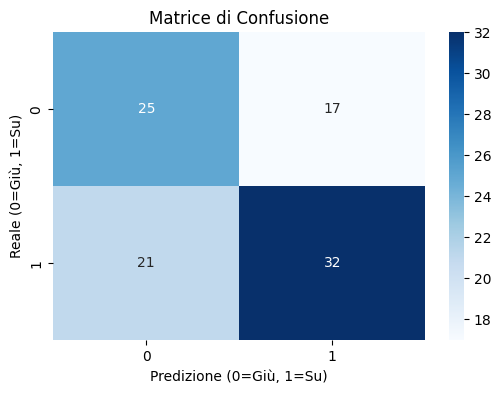

              precision    recall  f1-score   support

           0       0.54      0.60      0.57        42
           1       0.65      0.60      0.63        53

    accuracy                           0.60        95
   macro avg       0.60      0.60      0.60        95
weighted avg       0.60      0.60      0.60        95



In [85]:
from sklearn.metrics import confusion_matrix, classification_report

# Generiamo la matrice
cm = confusion_matrix(y_test, y_pred)

# Visualizziamola bene
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predizione (0=Giù, 1=Su)')
plt.ylabel('Reale (0=Giù, 1=Su)')
plt.title('Matrice di Confusione')
plt.show()

print(classification_report(y_test, y_pred))